# Fusion Cross-sections and Reactivities

This notebook walks through the two quantities that decide whether a fusion fuel is
worth building a reactor around:

- the **cross-section** $\sigma(E)$ — how likely two nuclei are to fuse when they collide at a given energy, and
- the **Maxwellian reactivity** $\langle\sigma v\rangle(T)$ — how fast they fuse on average in a hot, thermal plasma.

The rate of fusion in a thermonuclear plasma is governed by the cross-section of each reaction as a function of collision energy and by its Maxwellian-averaged reactivity as a function of temperature. Parametrizing these two quantities with the Bosch–Hale formulas for nine common reactions allows their peak values to be compared directly, showing why near-term magnetic and inertial confinement (ICF) reactors burn deuterium–tritium.

In [ ]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

REACTIONS = {
    "D(t,n)A": r"D(t,n)$\alpha$",
    "3He(d,p)A": r"$^3$He(d,p)$\alpha$",
    "D(d,p)T": r"D(d,p)T",
    "D(d,n)3He": r"D(d,n)$^3$He",
    "3He(3He,2p)A": r"$^3$He($^3$He,2p)$\alpha$",
    "3He(t,n+p)A": r"$^3$He(t,n+p)$\alpha$",
    "3He(t,d)A": r"$^3$He(t,d)$\alpha$",
    "T(t,2n)A": r"T(t,2n)$\alpha$",
    "11B(p,a)2A": r"$^{11}$B(p,$\alpha$)2$\alpha$",
}

## 1. What is a fusion cross-section?

Fire one nucleus at another and the **cross-section** $\sigma$ is the effective target
area for a reaction: a big $\sigma$ means "easy to hit," a small one means "rare." It
has units of area, quoted in **barns** ($1\,\text{b} = 10^{-28}\,\text{m}^2$ which literally
comes from as"big as a barn," a nuclear-physics joke). Here we plot it in $\text{m}^2$, so 
watch for the $10^{-28}$.

The wrinkle is that both nuclei are positively charged, so they repel. To fuse they must
get close enough (${\sim}$ a few femtometres) for the short-range strong force to take
over, which would mean climbing the **Coulomb barrier**:

$$U_C(r) = \frac{1}{4\pi\varepsilon_0}\frac{Z_1 Z_2 e^2}{r}.$$

For D-T that barrier is a few hundred keV, yet reactors run hot ions at only ${\sim}10$ keV.
Classically nothing would fuse. Fusion happens at all because of **quantum tunneling**
through the barrier which is is extremely sensitive to energy.
This is why $\sigma(E)$ climbs by many orders of magnitude over the plotted range.

## 2. The astrophysical S-factor and the Gamow factor

The steep energy dependence of $\sigma(E)$ comes almost entirely from Coulomb barrier
tunneling. Dividing it out leaves a factor that depends only on the nuclear interaction 
itself in both the strong-force matrix elements and resonances of the specific reaction. 
Gamow's tunneling probability through the barrier is:

$$P_\text{tunnel}(E) \;\propto\; \exp\!\left(-\frac{B_G}{\sqrt{E}}\right),
\qquad
B_G = \pi\,\alpha\,Z_1 Z_2\sqrt{2\,m_r c^2},$$

where $\alpha$ is the fine-structure constant, $m_r$ the reduced mass, and $B_G$ the
**Gamow constant** (units of $\sqrt{\text{keV}}$). Combining this with the geometric
$1/E$ scaling of the collision motivates writing

$$\boxed{\;\sigma(E) \;=\; \frac{S(E)}{E}\,\exp\!\left(-\frac{B_G}{\sqrt{E}}\right)\;}$$

The function $S(E)$ defined this way is the **astrophysical S-factor**. All the violent
energy dependence now lives in the two explicit factors; what remains in $S(E)$ is
*slowly varying* and captures the actual nuclear structure (resonances, matrix elements).
With this function $S(E)$ Bosch and Hale were able to create a slowly-varying function that
is easy to fit using a short formula. 

## 3. The Bosch–Hale parametrization

Bosch & Hale (*Nucl. Fusion* **32**, 611, 1992) represent the S-factor with a
**Padé approximant** which is a ratio of two polynomials:

$$S(E) \;=\;
\frac{A_1 + E\big(A_2 + E(A_3 + E(A_4 + E\,A_5))\big)}
     {1 + E\big(B_1 + E(B_2 + E(B_3 + E\,B_4))\big)}.$$

A rational function is used instead of a plain polynomial because it can bend around the
broad nuclear **resonances** (especially D-T's) that a polynomial fits poorly. Feed this
$S(E)$ back into the boxed formula from Section 2 and you have $\sigma(E)$ in closed form.

The coefficients $A_i, B_i$ (plus $B_G$) are obtained once, by fitting the expression to
evaluated nuclear data from R-matrix analyses and ENDF.

**Two backends.** Bosch & Hale only published Padé fits for the four light-ion reactions
(the two D-D branches, D-T, and D-$^3$He). This library therefore uses:

- **Bosch–Hale Padé fits** for those four reactions, and
- **ENDF scipy_curve_fit to Padé fits** for the remaining five ($^3$He-$^3$He, $^3$He-T, T-T, p-$^{11}$B),

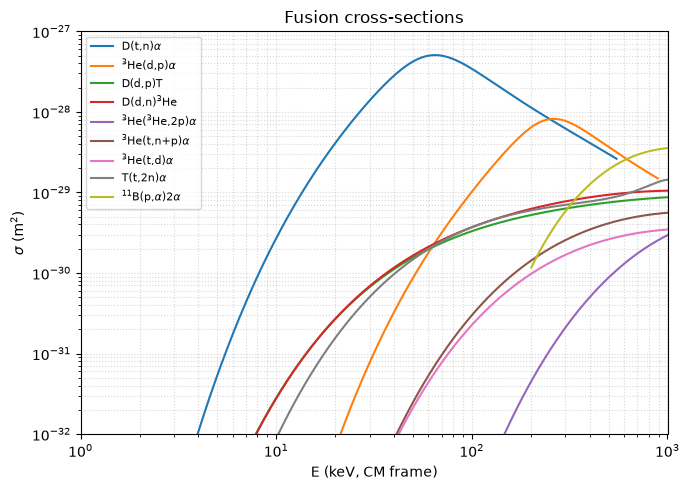

In [14]:
from plasmapy.formulary.fusion import fusion_cross_section

E = np.logspace(0, 3, 600) * u.keV

fig, ax = plt.subplots(figsize=(7, 5))
for r, label in REACTIONS.items():
    ax.loglog(E, fusion_cross_section(E, r, out_of_range="nan"), label=label)

ax.set_xlabel("E (keV, CM frame)")
ax.set_ylabel(r"$\sigma$ (m$^2$)")
ax.set_title("Fusion cross-sections")
ax.set_xlim(1, 1e3)
ax.set_ylim(1e-32, 1e-27)
ax.grid(visible=True, which="both", ls=":", alpha=0.5)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

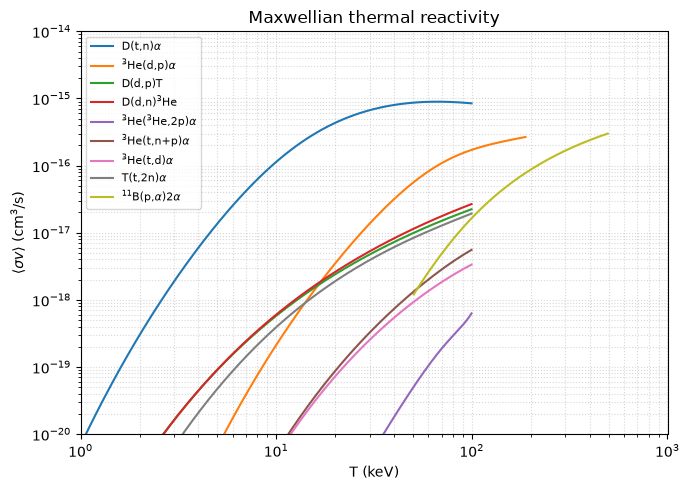

In [21]:
from plasmapy.formulary.fusion import fusion_reactivity

T = np.logspace(0, 3, 600) * u.keV

fig, ax = plt.subplots(figsize=(7, 5))
for r, label in REACTIONS.items():
    ax.loglog(
        T, fusion_reactivity(T, r, out_of_range="nan").to(u.cm**3 / u.s), label=label
    )

ax.set_xlabel("T (keV)")
ax.set_ylabel(r"$\langle\sigma v\rangle$ (cm$^3$/s)")
ax.set_title("Maxwellian thermal reactivity")
ax.set_xlim(1, 1e3)
ax.set_ylim(1e-20, 1e-14)
ax.grid(visible=True, which="both", ls=":", alpha=0.5)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()